# [LAB-02] 6. 계층적 튜닝・평가 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame, crosstab
from sklearn.metrics import silhouette_score

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


## 📚 2개는 너무 뭉뚱그린 것 아닌가 — 담당자를 늘린다면 몇 개로?

### 당신은 지난주 도매 거래처 440곳을 두 그룹으로 나눠 보고한 그 담당자입니다.

지난 보고에서 당신은 여섯 항목의 지출 패턴만으로 거래처를 2개로 나눴고, 한 무리가 호텔·레스토랑·카페(Horeca)로 거의 채워진다는 것을 확인했습니다. 팀장은 결과를 받아들이면서도 "2개는 너무 뭉뚱그린 것 같다. 담당자를 한 명 더 붙일 수 있으니 **몇 개로 나누는 것이 적절한지** 근거를 갖춰 다시 보고하라"고 합니다.

이번에는 군집 수를 2개부터 10개까지 바꿔 가며 점수를 비교하고, 최종적으로 고른 개수로 다시 나눈 뒤 **나무의 어느 높이에서 잘렸는지**, 그리고 **지난번 2개 결과와 무엇이 달라지는지**까지 확인해야 합니다.

데이터 준비는 지난번과 같습니다 — 채널·지역은 빼고, 큰 거래처 때문에 치우친 지출액을 완만하게 만든 뒤 표준화합니다.

### 💻 코드 작성

#### 데이터 가져오기

In [2]:
origin = load_data("wholesale_customers")
origin.head()

📚 이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### 전처리 (채널·지역 제외 / 치우침 완화 / 표준화)

In [ ]:
df1 = origin.drop(columns=["Channel", "Region"])

# 몇몇 큰 거래처 때문에 한쪽으로 심하게 치우친 금액을 완만하게 만든 뒤 표준화한다
df2 = my_prep.log_transform(df1, log_columns=list(df1.columns), verbose=False)
sdf = my_prep.scaling(df2, method="standard", verbose=False)

sdf.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.485,0.976,0.439,-1.508,0.643,0.408
1,0.089,0.991,0.650,0.135,0.764,0.624
2,0.018,0.891,0.454,0.377,0.802,1.758
3,0.516,-0.958,-0.084,1.140,-0.324,0.629
4,0.877,0.440,0.395,0.757,0.405,1.442


#### 군집수를 바꿔 가며 실루엣 스코어 확인

In [4]:
klist = list(range(2, 11))
s_items = []

for k in klist:
    # 이미 스케일링을 마쳤으므로 scaling=None (계층적 군집은 랜덤 요소가 없다)
    estimator, cdf = my_cluster.agglomerative(sdf, k=k, scaling=None, verbose=False, plot=False)

    s_items.append({"k": k, "score": round(silhouette_score(X=sdf, labels=estimator.labels_), 4)})

score_df = DataFrame(s_items).sort_values(by="score", ascending=False)
score_df

,k,score
0,2,0.263
1,3,0.235
2,4,0.190
3,5,0.178
8,10,0.168
7,9,0.166
6,8,0.164
5,7,0.154
4,6,0.152


#### 최종 모형 적합 (담당자를 한 명 더 붙일 수 있는 개수)

In [5]:
best_k = 3

estimator, cdf = my_cluster.agglomerative(sdf, k=best_k, scaling=None, plot=False)

# 해석은 원본 단위로 해야 하므로 원본 데이터에 군집 번호만 옮겨 붙인다
result_df = df1.copy()
result_df["그룹번호"] = cdf["그룹번호"]
result_df.head()

[계층적 군집] 군집 수 = 3, 연결 방법 = ward, 거리 = euclidean
  · 자른 높이(병합 거리) = 20.9851
  · 군집별 데이터 개수 : 0번 234개, 1번 90개, 2번 116개


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,그룹번호
0,12669,9656,7561,214,2674,1338,1
1,7057,9810,9568,1762,3293,1776,2
2,6353,8808,7684,2405,3516,7844,2
3,13265,1196,4221,6404,507,1788,0
4,22615,5410,7198,3915,1777,5185,2


#### 최종 모형의 실루엣과 덴드로그램

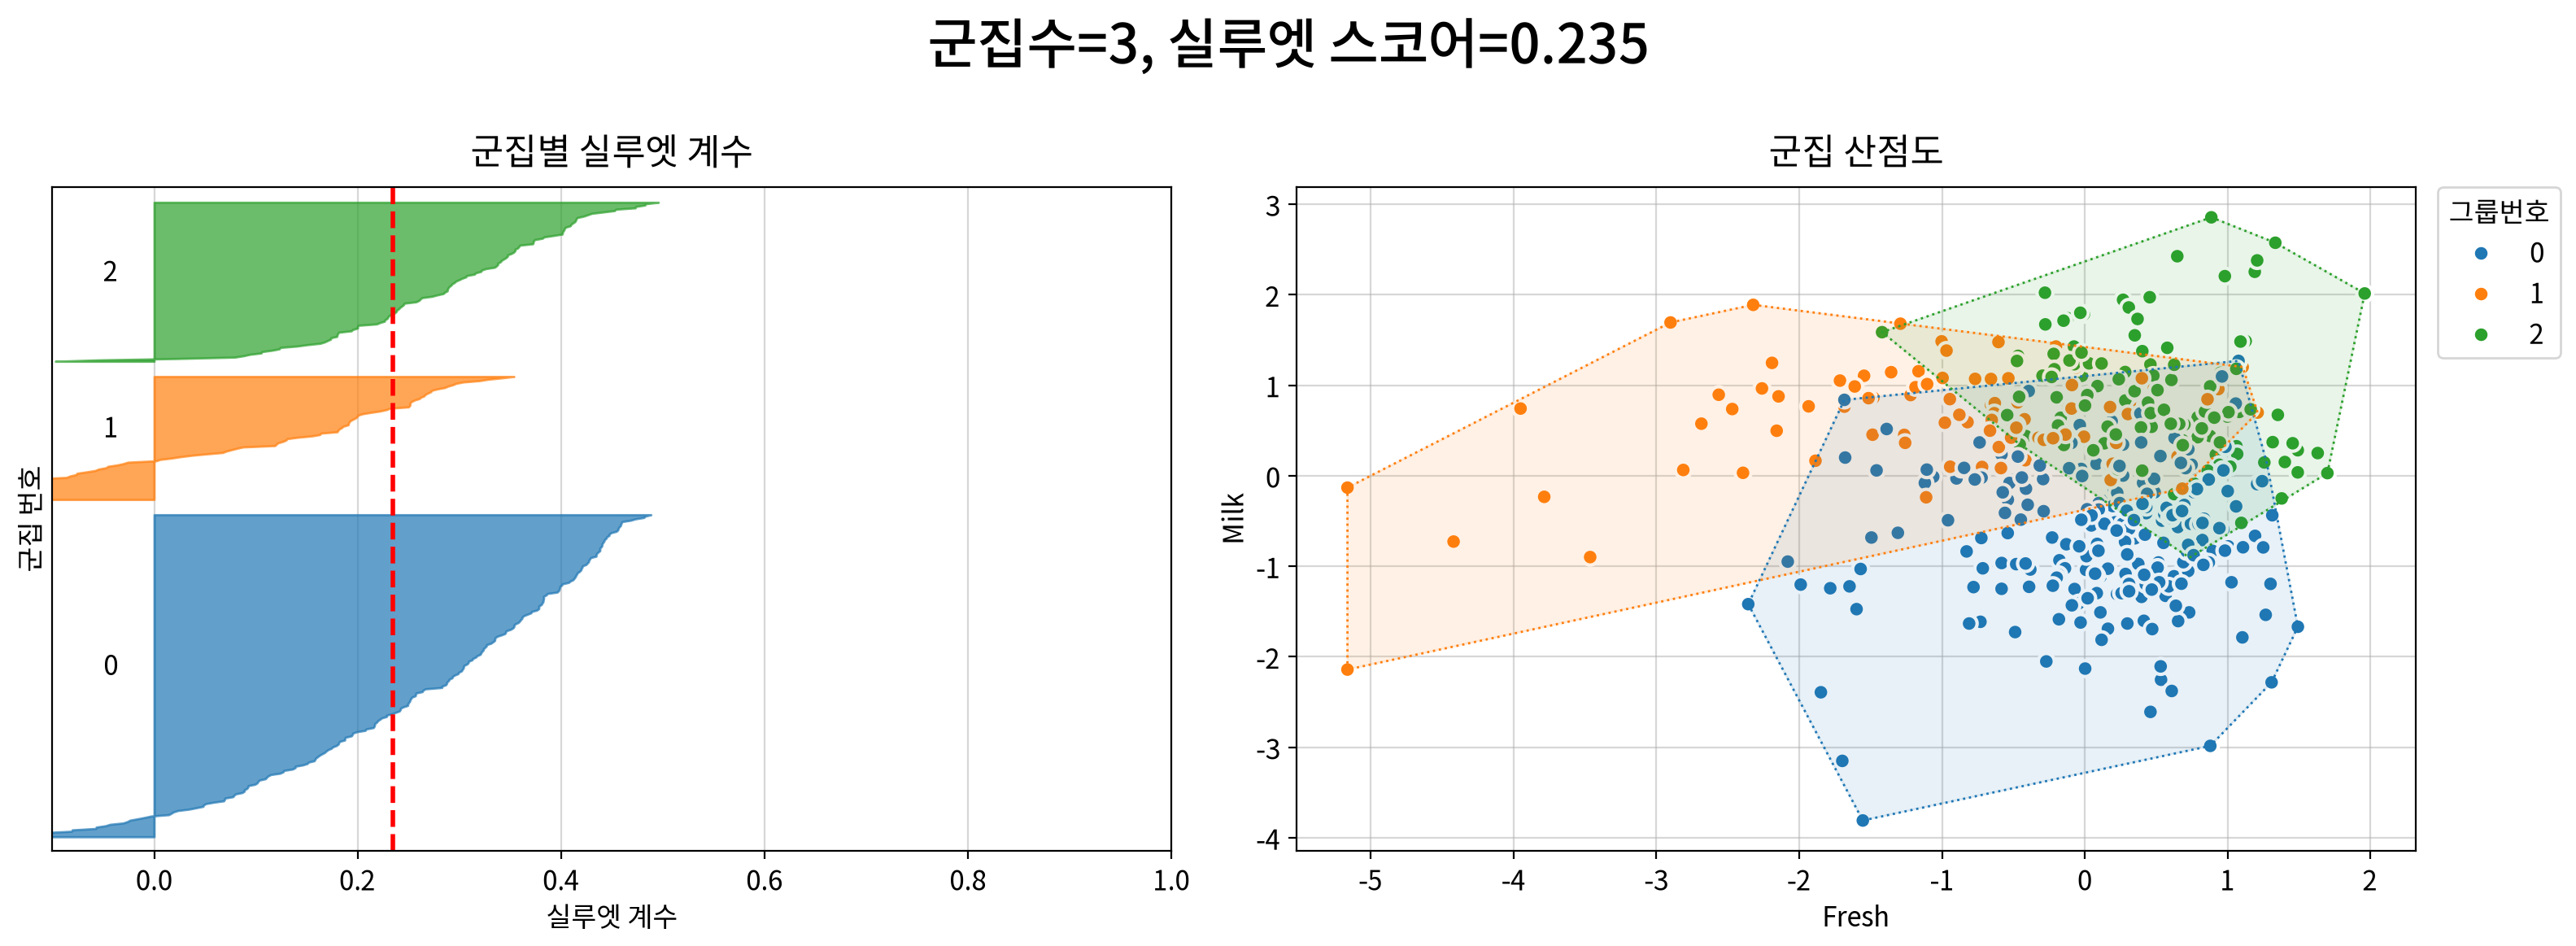

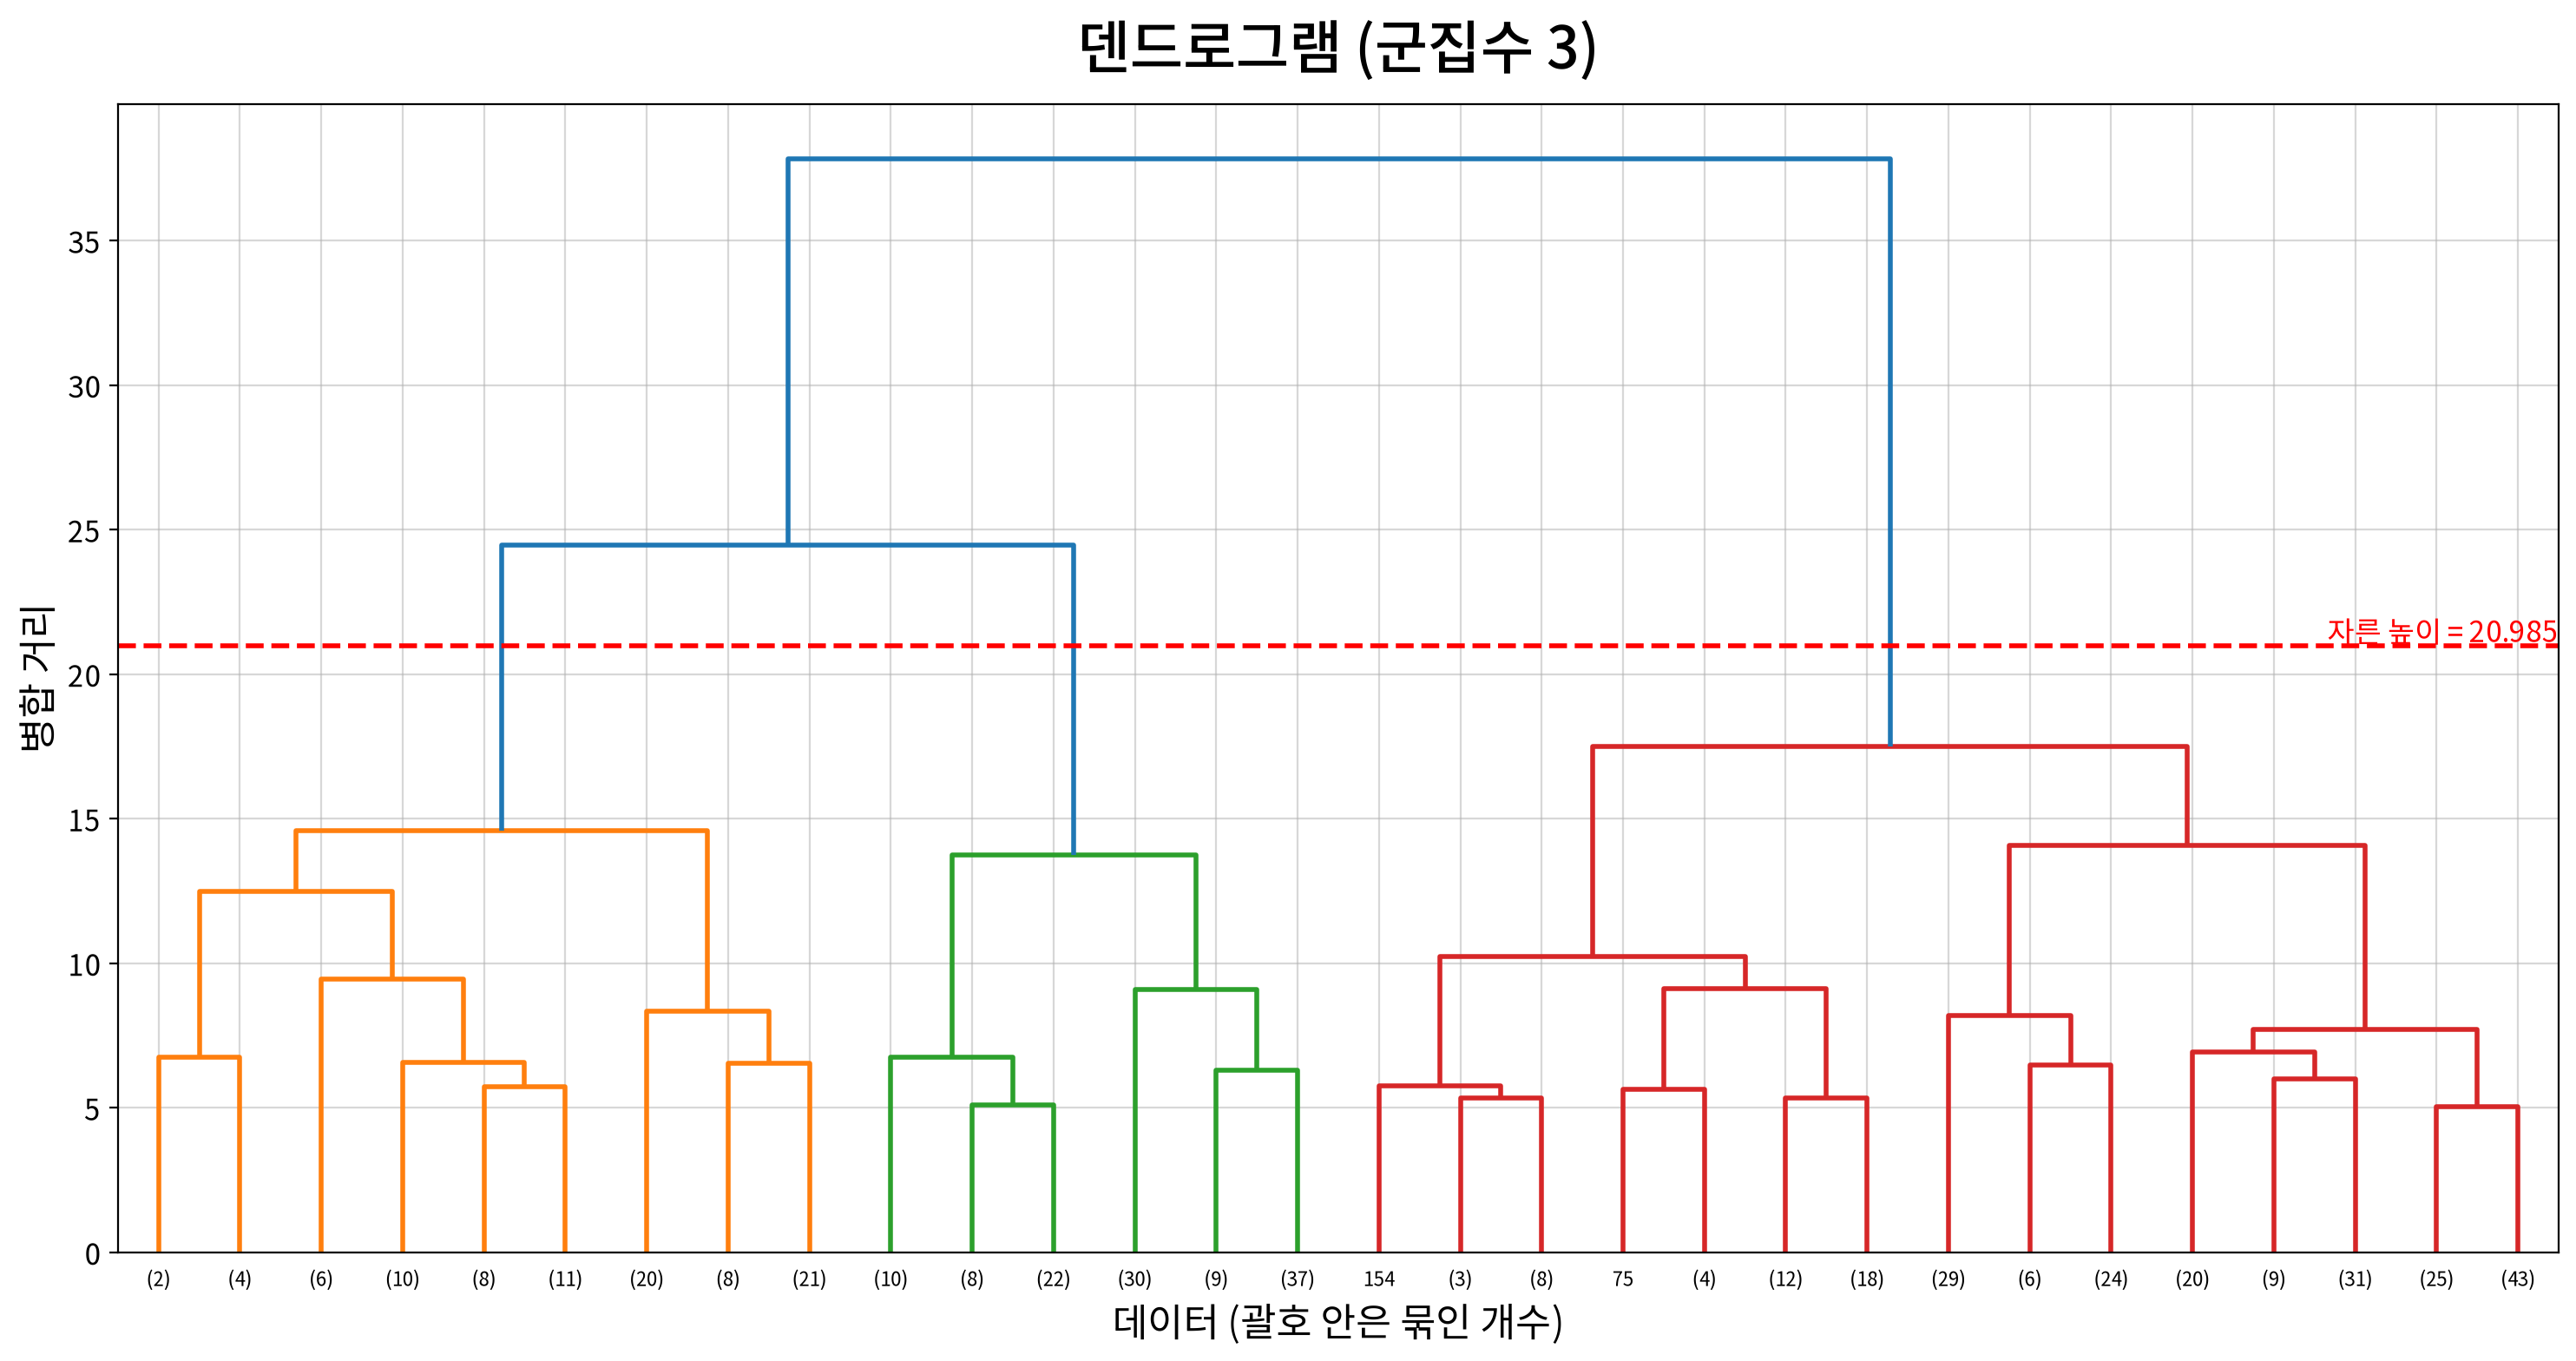

In [6]:
my_cluster.visualize_silhouette(estimator, cdf)

# 자른 높이도 모델에서 직접 찾아 빨간 점선으로 표시된다
my_cluster.plot_dendrogram(estimator, title=f"덴드로그램 (군집수 {best_k})", width=1500, height=800)

#### 지난번 2개 결과와 맞대어 보기

In [7]:
estimator2, cdf2 = my_cluster.agglomerative(sdf, k=2, scaling=None, verbose=False, plot=False)

print("2개로 나눴을 때 :", cdf2["그룹번호"].value_counts().sort_index().to_dict())
print("3개로 나눴을 때 :", cdf["그룹번호"].value_counts().sort_index().to_dict())

print("\n[2개(행) × 3개(열)]")
print(crosstab(cdf2["그룹번호"], cdf["그룹번호"]).to_string())

2개로 나눴을 때 : {0: 206, 1: 234}
3개로 나눴을 때 : {0: 234, 1: 90, 2: 116}

[2개(행) × 3개(열)]
그룹번호    0   1    2
그룹번호              
0       0  90  116
1     234   0    0


#### 실제 채널과 대조

In [8]:
ct = crosstab(result_df["그룹번호"], origin["Channel"])
ct.columns = ["Horeca", "Retail"]

print(ct.to_string())

print("\n[무리별 소매점(Retail) 비중]")
for c, row in ct.iterrows():
    print(f"  {c}번 무리({row.sum()}곳) : {row['Retail'] / row.sum() * 100:.1f}%")

      Horeca  Retail
그룹번호                
0        227       7
1         24      66
2         47      69

[무리별 소매점(Retail) 비중]
  0번 무리(234곳) : 3.0%
  1번 무리(90곳) : 73.3%
  2번 무리(116곳) : 59.5%


### 문제 풀이

#### 1. 군집 수를 2개부터 10개까지 바꿔 가며 "자기 무리와는 가깝고 옆 무리와는 먼가"를 점수로 재 보았습니다. 점수가 가장 높게 나오는 군집 수는 몇 개인가요? (개)

- **정답**: `2`
- **복습 개념**: 군집 수를 바꿔 가며 실루엣 스코어를 비교하는 튜닝 절차입니다. 계층적 군집은 랜덤 요소가 없어 같은 데이터라면 몇 번을 돌려도 결과가 같으므로, 개수만 바꿔 가며 점수를 모으면 됩니다.
- **풀이 접근**: 2개부터 10개까지 차례로 나눠 보고, 각 결과에 대해 데이터 하나하나의 실루엣 계수를 평균 낸 값을 모읍니다. 그 표를 점수 기준으로 내림차순 정렬해 맨 위를 읽습니다.
- **근거(계산 결과)**: 점수는 2개일 때 **0.263** 으로 가장 높고, 3개 0.235, 4개 0.190, 5개 0.178 로 떨어집니다. 결과표의 맨 윗줄이 `k = 2` 입니다.
- **헷갈리기 쉬운 점**: 실루엣이 2를 가장 높게 주는 것은 이 데이터만의 특징이 아닙니다. 크게 두 덩어리로 갈리는 데이터에서는 거의 언제나 2가 최고점을 받습니다. 점수가 가장 높다는 것과 쓸모 있다는 것은 다른 이야기이며, 지난 보고에서 팀장이 "뭉뚱그렸다"고 되물은 이유가 바로 이것입니다.

#### 2. 담당자를 한 명 더 붙일 수 있으므로 2개로 두는 선택지는 접어 두기로 했습니다. 2개를 뺀 나머지 중에서 점수가 가장 높은 군집 수는 몇 개인가요? (개)

- **정답**: `3`
- **복습 개념**: 지표와 목적을 함께 놓고 최종 개수를 정하는 단계입니다. 지표는 후보를 좁혀 줄 뿐이고, "담당자를 몇 명 둘 수 있는가" 같은 현실 조건이 마지막 결정을 합니다.
- **풀이 접근**: 정렬된 결과표에서 맨 위(2개)를 제외한 다음 줄을 읽습니다. 점수가 이후로 계속 떨어지는지도 함께 확인해 두면, 3개가 우연히 높은 것이 아니라는 근거가 됩니다.
- **근거(계산 결과)**: 2개(0.263) 다음이 3개(**0.235**)이고, 4개 0.190, 5개 0.178, 6개 0.152 로 계속 낮아집니다. 6개 이후로 다시 조금 오르지만(10개 0.168) 3개 수준에는 미치지 못합니다.
- **함께 생각해 볼 점**: 8·9·10개에서 점수가 다시 오르는 이유를 생각해 보세요. 잘게 쪼갤수록 각 무리는 작고 촘촘해져서 점수가 회복되는 경향이 있습니다. 그래서 점수 곡선의 끝자락에서 최고점을 고르면 "거래처 6곳짜리 무리"까지 담당자를 붙이는 결론에 이르게 됩니다.

#### 3. 최종적으로 고른 개수로 다시 나눈 뒤 덴드로그램을 확인했습니다. 나무를 자른 높이(병합 거리)는 얼마인가요? (소수 첫째 자리)

- **정답**: `21.0`
- **복습 개념**: 덴드로그램의 세로축은 "얼마나 먼 거리에서 합쳤는가"입니다. 군집 수를 지정해 나눈 경우에도 그 개수가 되는 높이가 존재하며, 그 높이에 가로선을 그으면 선과 만나는 가지의 수가 곧 군집 수가 됩니다.
- **풀이 접근**: 고른 개수로 군집화한 뒤 덴드로그램을 그리면 자른 높이가 가로선으로 표시됩니다. 마지막으로 합친 거리와 아직 합치지 않은 다음 거리의 사이가 그 높이입니다.
- **근거(계산 결과)**: 출력의 `자른 높이(병합 거리) = 20.9851` 이므로 소수 첫째 자리로 **21.0** 입니다. 덴드로그램에서 이 높이의 빨간 점선과 만나는 가지가 정확히 3개입니다. 참고로 2개로 나눌 때의 높이는 31.1로, 두 높이 사이에는 아무 병합도 일어나지 않습니다.
- **실무 포인트**: 높이 21과 31 사이가 비어 있다는 것은 "2개와 3개 사이에 다른 선택지가 없다"는 뜻입니다. 반대로 가지가 촘촘한 낮은 높이에서는 기준을 조금만 움직여도 군집 수가 크게 흔들립니다. 보고할 때 개수 하나만 말하는 것보다 이 그림을 함께 보이는 편이 설득력이 큽니다.

#### 4. 지난번 2개로 나눈 결과와 이번 3개로 나눈 결과를 맞대어 보면, 한 무리는 손대지 않은 채 다른 한 무리만 둘로 쪼개집니다. 그대로 유지된 무리에 속한 거래처는 몇 곳인가요? (곳)

- **정답**: `234`
- **복습 개념**: 계층적 군집의 가장 큰 특징인 "포개짐"입니다. 나무를 더 낮은 높이에서 자르는 것이므로 이미 갈라진 가지가 다시 합쳐지는 일은 없고, 기존 무리가 그대로 남거나 더 잘게 갈라질 뿐입니다.
- **풀이 접근**: 2개로 나눈 결과와 3개로 나눈 결과의 군집 번호로 교차표를 만듭니다. 한 행의 값이 한 칸에만 몰려 있으면 그 무리는 그대로 유지된 것이고, 두 칸으로 나뉘어 있으면 쪼개진 것입니다.
- **근거(계산 결과)**: 교차표에서 2개 기준 1번 무리는 **234곳 전부**가 3개 기준 0번 무리로 그대로 갑니다. 반면 2개 기준 0번 무리(206곳)는 90곳과 116곳으로 갈라집니다. 234 + 90 + 116 = 440곳입니다.
- **함께 생각해 볼 점**: 지난 단원에서 같은 데이터를 KMeans로 2개와 3개로 나눠 비교하면 이런 관계가 성립하지 않습니다. 중심점을 다시 잡고 처음부터 배정하므로, 3개로 늘렸을 때 두 무리 전체가 뒤섞이는 일이 흔합니다. "개수를 늘려도 앞의 결정이 무너지지 않는다"는 점이 담당자 배정처럼 단계적으로 조직을 키워야 할 때 계층적 군집이 편한 이유입니다.

#### 5. 3개로 나눈 결과를 기존 거래처의 실제 채널과 맞춰 보면, 소매점(Retail)이 차지하는 비중이 가장 높은 무리가 하나 있습니다. 그 무리에 속한 거래처는 몇 곳인가요? (곳)

- **정답**: `90`
- **복습 개념**: 군집 결과를 이미 알고 있는 라벨과 대조해 각 무리의 정체를 읽는 마지막 단계입니다. 개수를 늘렸을 때 새로 생긴 무리가 무엇을 의미하는지 확인해야 담당자 배정의 근거가 됩니다.
- **풀이 접근**: 군집 번호와 채널로 교차표를 만든 뒤, 무리마다 소매점이 차지하는 비율을 계산해 가장 높은 무리를 찾습니다. 거래처 수가 무리마다 다르므로 개수가 아니라 비율로 비교해야 합니다.
- **근거(계산 결과)**: 0번 무리(234곳)는 Horeca 227곳으로 소매점 비중이 3.0%, 1번 무리(**90곳**)는 소매점 66곳으로 73.3%, 2번 무리(116곳)는 69곳으로 59.5%입니다. 비중이 가장 높은 것은 90곳짜리 무리입니다.
- **결론**: 당신이 팀장에게 보고할 내용은 이렇습니다. 3개로 늘려도 **호텔·레스토랑·카페 무리(234곳)는 통째로 유지되므로 그 담당자는 바뀌지 않고**, 지난번 206곳짜리 무리만 90곳과 116곳으로 갈라져 새 담당자가 맡을 몫이 됩니다. 다만 새로 갈라진 두 무리 모두 소매점이 완전히 걸러지지는 않았습니다(73.3%와 59.5%). 지출 패턴만으로는 소매점을 한 덩어리로 모으지 못한다는 뜻이므로, 채널까지 정확히 갈라내는 것이 목적이라면 지금 필요한 것은 더 많은 무리가 아니라 **채널을 구분해 줄 다른 변수**입니다. 소매점 비중이 73.3%로 가장 높은 90곳짜리 무리부터 소매 전담 담당자에게 넘기는 것이 현실적인 절충안입니다.